--- Executive Summary ---
Total Instances: 450
Feasibility Solved: 187 (41.6%)
Multiflow Solved:   283 (62.9%)

--- Direct Head-to-Head (Common Solved: 187) ---
Multiflow Faster: 177 instances (94.7%)
Feasibility Faster: 10 instances
Crossover Density Threshold: 0.1897


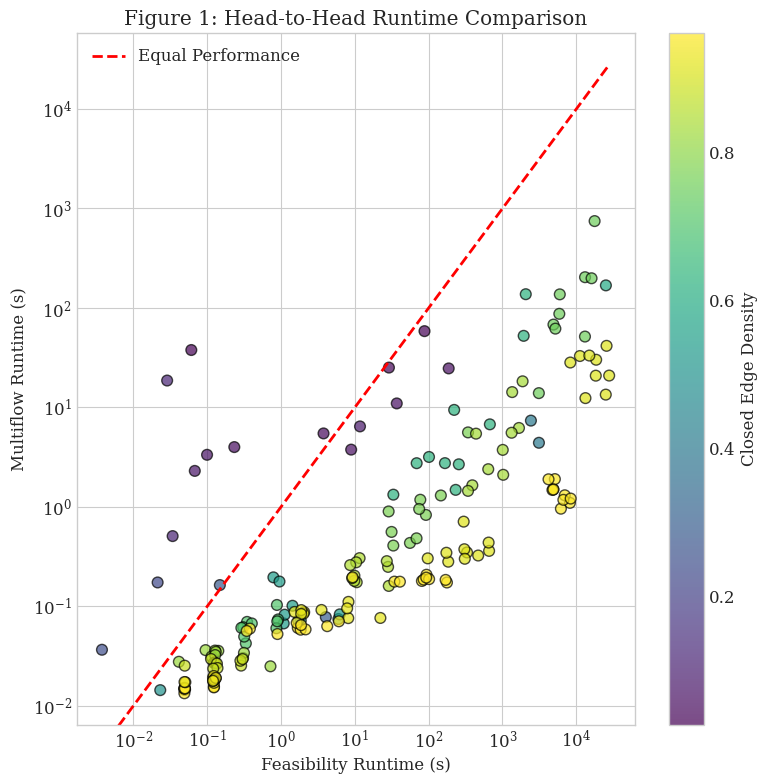

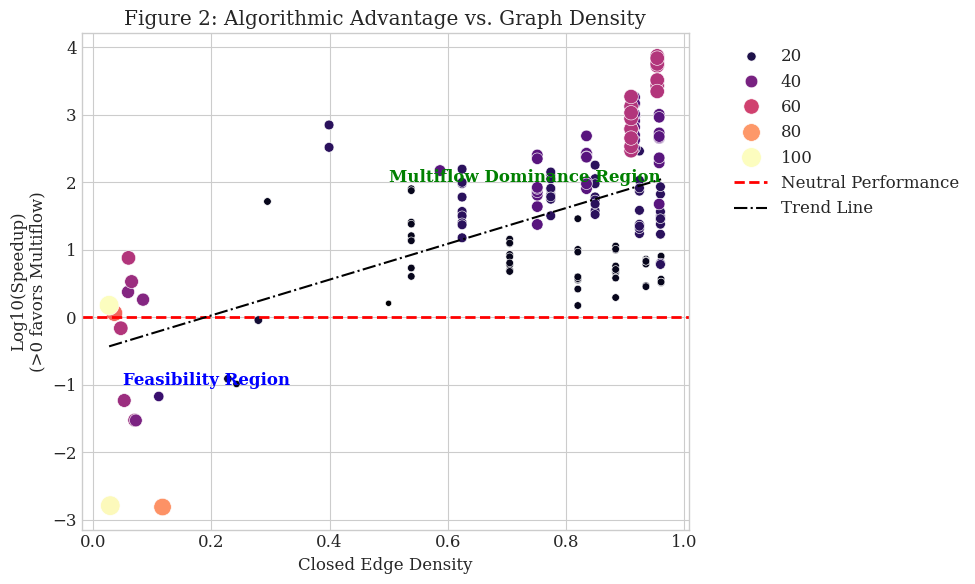

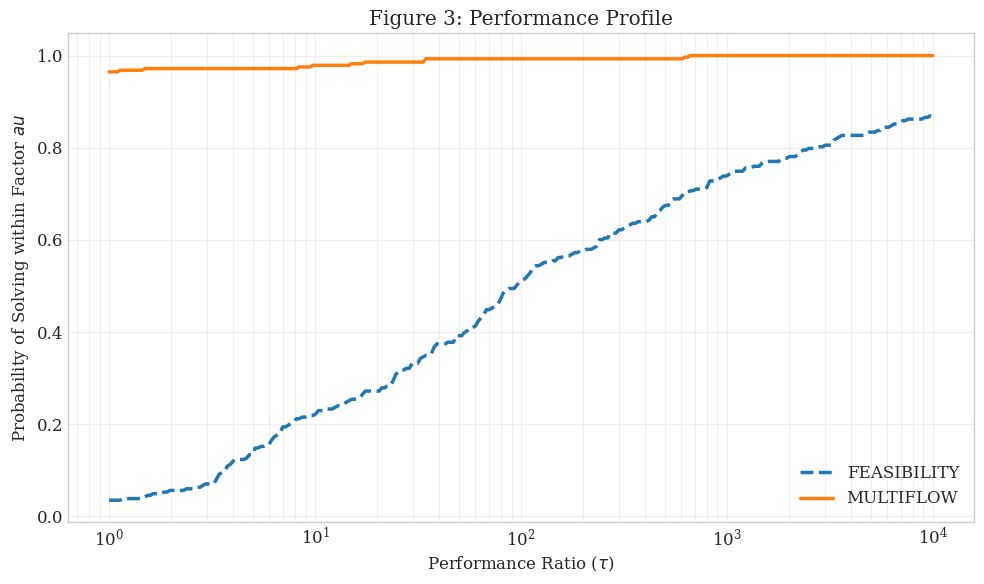

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Set academic style for plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

def generate_analysis(file_path):
    # 1. Data Loading and Preprocessing
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("Error: File not found. Please ensure 'metrics_with_invariants.csv' is in the directory.")
        return

    # Filter for relevant columns
    cols = ['instance', 'algorithm', 'runtime', 'status', 'closed_edge_density', 'num_nodes']
    df = df[cols]

    # Pivot to create a side-by-side comparison (Broad Format)
    df_pivot = df.pivot(index='instance', columns='algorithm', values=['runtime', 'status'])
    # Flatten hierarchical columns
    df_pivot.columns = ['_'.join(col).strip() for col in df_pivot.columns.values]
    
    # Re-attach invariant features (density, nodes)
    invariants = df.groupby('instance')[['closed_edge_density', 'num_nodes']].first()
    df_pivot = df_pivot.join(invariants)

    # 2. Comparative Statistics
    # Define "Solved" as status == 2
    feas_solved = (df_pivot['status_FEASIBILITY'] == 2).sum()
    multi_solved = (df_pivot['status_MULTIFLOW'] == 2).sum()
    
    print("--- Executive Summary ---")
    print(f"Total Instances: {len(df_pivot)}")
    print(f"Feasibility Solved: {feas_solved} ({feas_solved/len(df_pivot):.1%})")
    print(f"Multiflow Solved:   {multi_solved} ({multi_solved/len(df_pivot):.1%})")

    # Filter for instances solved by BOTH (for fair runtime comparison)
    common = df_pivot[(df_pivot['status_FEASIBILITY'] == 2) & (df_pivot['status_MULTIFLOW'] == 2)].copy()
    
    # Calculate Speedup (Ratio > 1 means Multiflow is faster)
    common['speedup'] = common['runtime_FEASIBILITY'] / common['runtime_MULTIFLOW']
    common['log_speedup'] = np.log10(common['speedup'])
    
    multiflow_wins = (common['speedup'] > 1).sum()
    print(f"\n--- Direct Head-to-Head (Common Solved: {len(common)}) ---")
    print(f"Multiflow Faster: {multiflow_wins} instances ({multiflow_wins/len(common):.1%})")
    print(f"Feasibility Faster: {len(common) - multiflow_wins} instances")

    # Calculate Threshold
    slope, intercept, _, _, _ = linregress(common['closed_edge_density'], common['log_speedup'])
    threshold = -intercept / slope
    print(f"Crossover Density Threshold: {threshold:.4f}")

    # 3. Visualization

    # Plot A: Scatter Plot (Runtime)
    plt.figure(figsize=(8, 8))
    # Color points by density
    sc = plt.scatter(common['runtime_FEASIBILITY'], common['runtime_MULTIFLOW'], 
                     c=common['closed_edge_density'], cmap='viridis', 
                     alpha=0.7, edgecolors='k', s=60)
    plt.colorbar(sc, label='Closed Edge Density')
    
    # Diagonal line (Equal performance)
    limit = max(common['runtime_FEASIBILITY'].max(), common['runtime_MULTIFLOW'].max())
    plt.plot([0, limit], [0, limit], 'r--', label='Equal Performance', linewidth=2)
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Feasibility Runtime (s)')
    plt.ylabel('Multiflow Runtime (s)')
    plt.title('Figure 1: Head-to-Head Runtime Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot B: Speedup vs Density (Threshold)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=common, x='closed_edge_density', y='log_speedup', 
                    hue='num_nodes', palette='magma', size='num_nodes', sizes=(20, 200))
    
    plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Neutral Performance')
    
    # Add Trend Line
    x_vals = np.linspace(common['closed_edge_density'].min(), common['closed_edge_density'].max(), 100)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color='black', linestyle='-.', label='Trend Line')
    
    # Annotate Zones
    plt.text(0.05, -1, 'Feasibility Region', color='blue', fontweight='bold')
    plt.text(0.5, 2, 'Multiflow Dominance Region', color='green', fontweight='bold')
    
    plt.xlabel('Closed Edge Density')
    plt.ylabel('Log10(Speedup)\n(>0 favors Multiflow)')
    plt.title('Figure 2: Algorithmic Advantage vs. Graph Density')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Plot C: Performance Profile
    # Calculate ratios relative to the BEST time for each instance
    # We include all instances where at least one solved it
    solved_any = df_pivot[(df_pivot['status_FEASIBILITY'] == 2) | (df_pivot['status_MULTIFLOW'] == 2)].copy()
    
    # Set timeout for unsolved algorithms in this subset
    max_time = df['runtime'].max()
    solved_any.loc[solved_any['status_FEASIBILITY'] != 2, 'runtime_FEASIBILITY'] = max_time * 10
    solved_any.loc[solved_any['status_MULTIFLOW'] != 2, 'runtime_MULTIFLOW'] = max_time * 10
    
    min_time = solved_any[['runtime_FEASIBILITY', 'runtime_MULTIFLOW']].min(axis=1)
    
    ratios_feas = solved_any['runtime_FEASIBILITY'] / min_time
    ratios_multi = solved_any['runtime_MULTIFLOW'] / min_time
    
    tau = np.logspace(0, 4, 300) # Tau from 1 to 10000
    
    y_feas = [np.mean(ratios_feas <= t) for t in tau]
    y_multi = [np.mean(ratios_multi <= t) for t in tau]
    
    plt.figure(figsize=(10, 6))
    plt.plot(tau, y_feas, label='FEASIBILITY', linewidth=2.5, linestyle='--')
    plt.plot(tau, y_multi, label='MULTIFLOW', linewidth=2.5)
    
    plt.xscale('log')
    plt.xlabel(r'Performance Ratio ($\tau$)')
    plt.ylabel('Probability of Solving within Factor $\tau$')
    plt.title('Figure 3: Performance Profile')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Ensure the csv file is in the same directory
    generate_analysis(r'A:\Users\evellynsc\Documents\workspace\arboreal-jump-number-algorithms\metrics_with_invariants.csv')